<a href='http://www.oddbox.co.uk'> <img src='https://images.prismic.io/oddbox/Z1m1ppbqstJ98Vin_logo-1-.png?auto=format,compress' /></a>

## Box Orders Forecasts

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from datetime import timedelta
import warnings
warnings.filterwarnings("ignore")

## Read and Clean Data

In [82]:
df_box_orders = pd.read_csv('data.csv')
df_box_orders['week'] = pd.to_datetime(df_box_orders['week'])

## Analyse Data

In [83]:
df_box_orders.head()

,week,box_type,box_orders,is_marketing_week,holiday_week,weekly_subscribers,fortnightly_subscribers
0,2024-04-15,LFV,79,False,False,483,167.0
1,2024-04-15,LV,79,False,False,483,167.0
2,2024-04-15,MFV,84,False,False,483,167.0
3,2024-04-15,MV,78,False,False,483,167.0
4,2024-04-15,SFV,82,False,False,483,167.0


### Clean non-numeric data

Attempting ```df_box_orders['box_orders'] = df_box_orders['box_orders'].astype(int)``` gives an error, so there may be invalid values

We can find the culprit by using the code block below:

In [84]:

df_box_orders['box_orders_invalid_dtype'] = pd.to_numeric(df_box_orders['box_orders'], errors='coerce').isna()
df_box_orders[df_box_orders['box_orders_invalid_dtype']==True]

,week,box_type,box_orders,is_marketing_week,holiday_week,weekly_subscribers,fortnightly_subscribers,box_orders_invalid_dtype
43,2024-05-20,MV,1O0,True,False,510,179.0,True


We can now convert the 'box_orders' field to numeric

In [85]:
df_box_orders['box_orders'] = df_box_orders['box_orders'].replace('1O0', '100')
df_box_orders['box_orders'] = pd.to_numeric(df_box_orders['box_orders'], errors='coerce')
df_box_orders.drop('box_orders_invalid_dtype', axis=1, inplace=True)

Checking the full dataset shows that fortnightly_subscribers comprises 415 non-null values, so we may have to impute the missing data

In [86]:
df_box_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   week                     416 non-null    datetime64[ns]
 1   box_type                 416 non-null    object        
 2   box_orders               416 non-null    int64         
 3   is_marketing_week        416 non-null    bool          
 4   holiday_week             416 non-null    bool          
 5   weekly_subscribers       416 non-null    int64         
 6   fortnightly_subscribers  415 non-null    float64       
dtypes: bool(2), datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 17.2+ KB


In [87]:
df_box_orders.describe()

,week,box_orders,weekly_subscribers,fortnightly_subscribers
count,416,416.000000,416.000000,415.000000
mean,2024-10-10 12:00:00,80.899038,498.769231,148.440964
min,2024-04-15 00:00:00,49.000000,412.000000,121.000000
25%,2024-07-13 06:00:00,73.000000,467.500000,134.500000
50%,2024-10-10 12:00:00,81.000000,490.000000,148.000000
75%,2025-01-07 18:00:00,89.000000,541.750000,160.000000
max,2025-04-07 00:00:00,110.000000,571.000000,189.000000
std,NaN,11.329645,43.462928,16.253896


we can determine the number of unique values

In [ ]:
df_box_orders.nunique()

week                       52
box_type                    8
box_orders                 58
is_marketing_week           2
holiday_week                2
weekly_subscribers         47
fortnightly_subscribers    36
dtype: int64

### Add initial params

In [131]:
n_box_types = 8

### Impute missing data

We should ideally also check for missing weeks etc, but for now we just check for missing values etc.

In [88]:
df_box_orders[df_box_orders['fortnightly_subscribers'].isna()]

,week,box_type,box_orders,is_marketing_week,holiday_week,weekly_subscribers,fortnightly_subscribers
68,2024-06-10,SFV,94,False,False,554,NaN


Since this is a time-series forecast, we can only use data known at the time of forecasting for this method to be useable in future

In [89]:
df_box_orders[(df_box_orders['box_type']=='SFV') & (df_box_orders['week']<='2024-06-10')]

,week,box_type,box_orders,is_marketing_week,holiday_week,weekly_subscribers,fortnightly_subscribers
4,2024-04-15,SFV,82,False,False,483,167.0
12,2024-04-22,SFV,73,False,False,453,176.0
20,2024-04-29,SFV,76,False,False,501,173.0
28,2024-05-06,SFV,93,True,False,556,170.0
36,2024-05-13,SFV,82,False,True,546,174.0
44,2024-05-20,SFV,107,True,False,510,179.0
52,2024-05-27,SFV,82,False,False,544,168.0
60,2024-06-03,SFV,102,False,False,561,159.0
68,2024-06-10,SFV,94,False,False,554,NaN


<Axes: xlabel='week'>

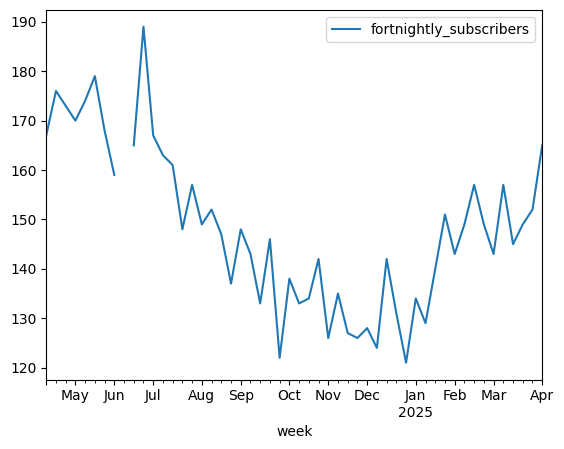

In [90]:
df_box_orders[(df_box_orders['box_type']=='SFV')][['week','fortnightly_subscribers']].set_index('week').plot()

We check the time-series for weeks which are most similar to our missing fortnightly_subscribers dataset, thus those having no marketing promotions and no holidays

<Axes: xlabel='week'>

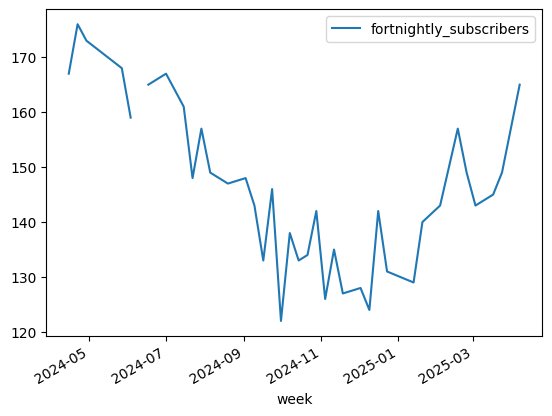

In [91]:
df_box_orders[(df_box_orders['box_type']=='SFV') &
            #   (df_box_orders['week']<='2024-06-10') & 
              (df_box_orders['is_marketing_week']==False) &
              (df_box_orders['holiday_week']==False)
              ][['week','fortnightly_subscribers']].set_index('week').plot()

We use the median of the prior periods (less susceptible to outliers than mean)

In [92]:
df_box_orders[(df_box_orders['box_type']=='SFV') &
              (df_box_orders['week']<'2024-06-10') & # using < rather than <= to ensure current week isn't included in mean calculation
              (df_box_orders['is_marketing_week']==False) &
              (df_box_orders['holiday_week']==False)
              ]['fortnightly_subscribers'].median()

168.0

In a production setting, we would usually write this as a function which is dynamic enough to look at the parameters of the imputed field and find a robust analog (e.g. median) from prior periods, given that we have enough samples or we could roll-up if the sample size is too small

In [93]:
df_box_orders['fortnightly_subscribers'] = df_box_orders['fortnightly_subscribers'].fillna(168.0)

## Analyze the cleaned time-series

In [141]:
df_box_orders.groupby(['box_type', 'week']).agg({"box_orders":sum}).reset_index()

,box_type,week,box_orders
0,FB,2024-04-15,82
1,FB,2024-04-22,90
2,FB,2024-04-29,80
3,FB,2024-05-06,94
4,FB,2024-05-13,65
...,...,...,...
411,XSFV,2025-03-10,81
412,XSFV,2025-03-17,89
413,XSFV,2025-03-24,85
414,XSFV,2025-03-31,73


In [165]:
df_box_types_for_ts = df_box_orders.groupby(['box_type', 'week']).agg({"box_orders":sum}).reset_index()

### Plot time-series for each box type

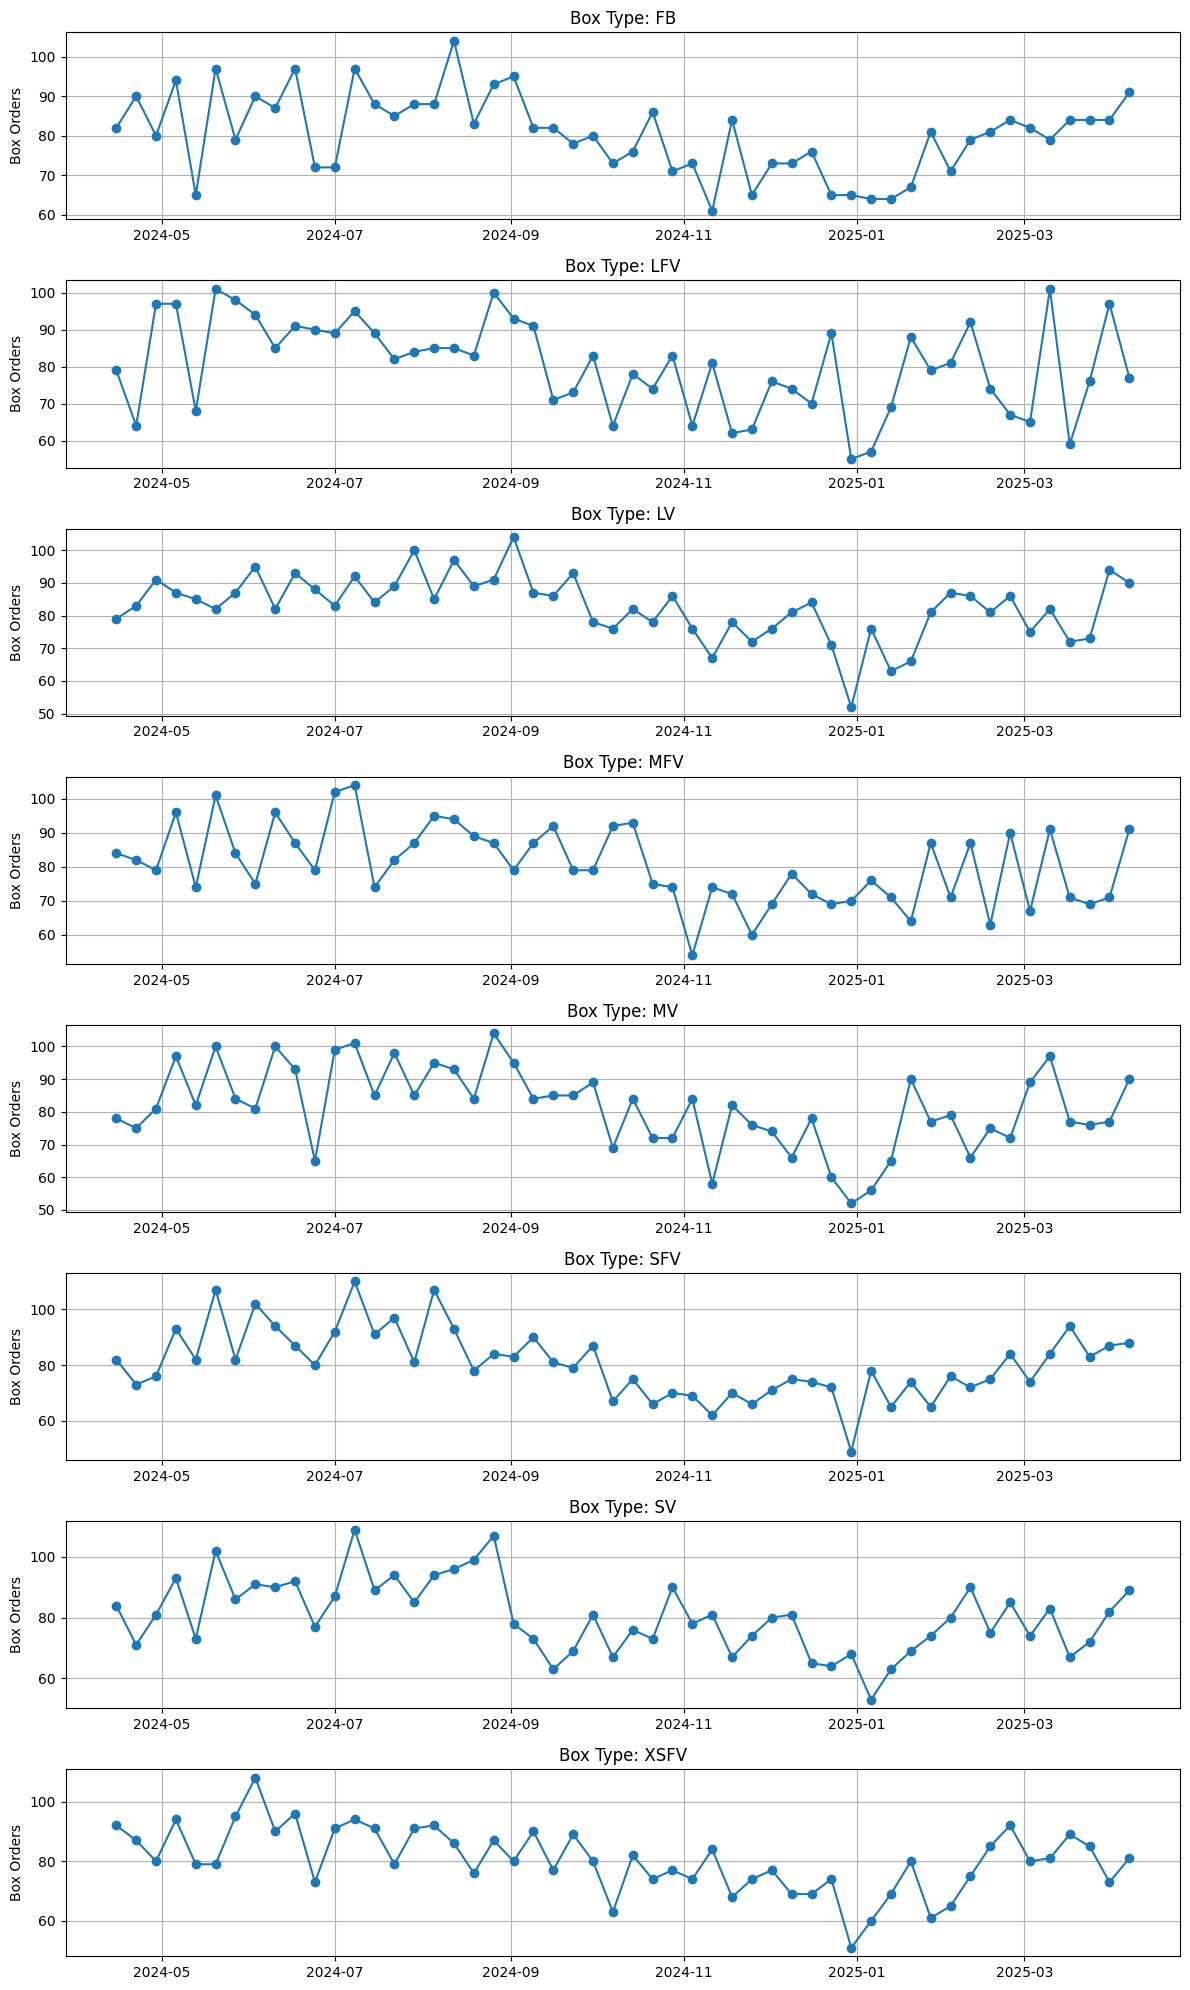

In [ ]:
fig, axes = plt.subplots(n_box_types, 1, figsize=(12, 2.5 * n_box_types), sharex=False)
for ax, (ptype, group) in zip(axes, df_box_types_for_ts.groupby('box_type')):
    ax.plot(group['week'], group['box_orders'], marker='o')
    ax.set_title(f"Box Type: {ptype}")
    ax.set_ylabel("Box Orders")
    ax.grid(True)
    plt.tight_layout()

### Run ETS Decomposition

Here we check the error, trend and seasonality components

In [144]:
df_box_orders.groupby(['box_type', 'week']).agg({"box_orders":sum}).reset_index().head(53)

,box_type,week,box_orders
0,FB,2024-04-15,82
1,FB,2024-04-22,90
2,FB,2024-04-29,80
3,FB,2024-05-06,94
4,FB,2024-05-13,65
5,FB,2024-05-20,97
6,FB,2024-05-27,79
7,FB,2024-06-03,90
8,FB,2024-06-10,87
9,FB,2024-06-17,97


Plot an example of ETS decomposition for a box type over the course of a year

<Figure size 640x480 with 0 Axes>

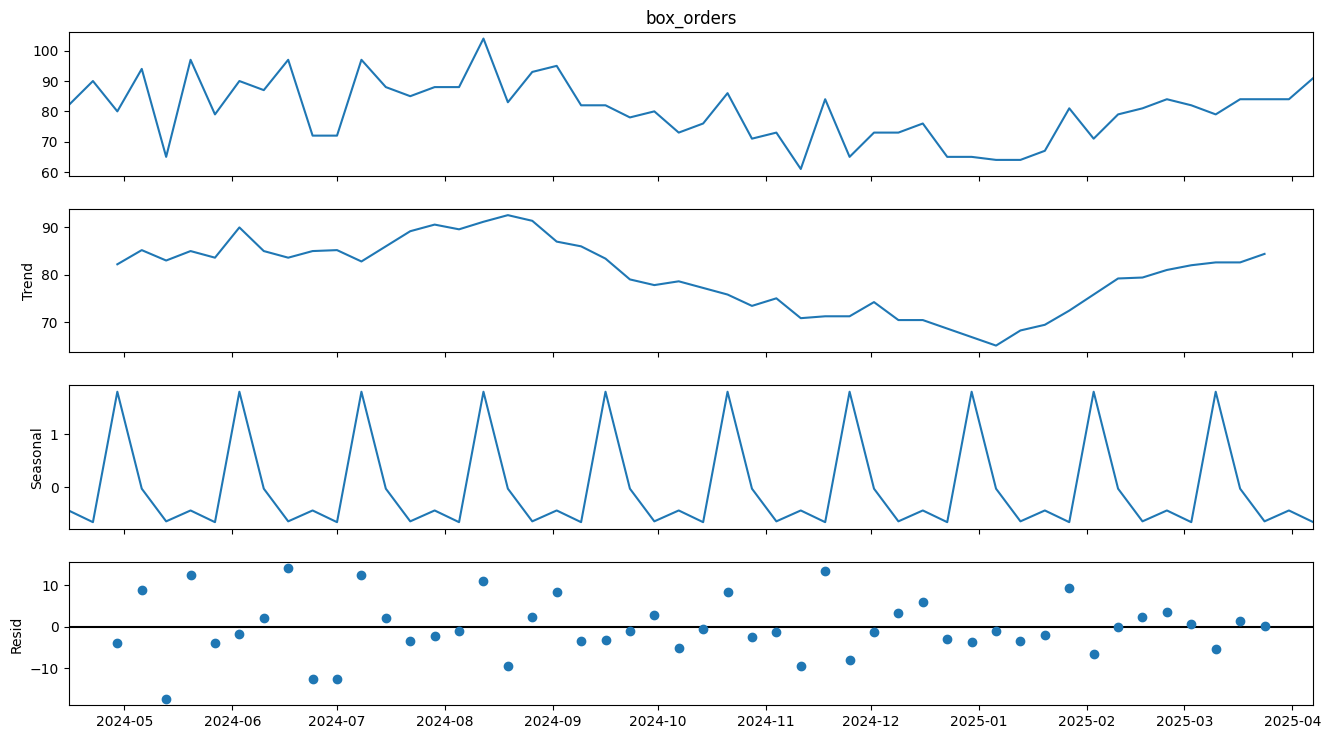

In [160]:
decomposition = seasonal_decompose(df_box_orders.groupby(['box_type', 'week']).agg({"box_orders":sum}).reset_index().head(52).set_index('week')['box_orders'], period=5)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

### Test Stationarity

We can use an augmented Dickey–Fuller test (ADF) to test the null hypothesis that a unit root is present in a time series sample. The alternative hypothesis is different depending on which version of the test is used, but is usually stationarity or trend-stationarity.

We are trying to check whether to accept the:
* Null Hypothesis **H0** (that the time series has a unit root, indicating it is non-stationary) or reject **H0** and go with the 
* Alternative Hypothesis **H1** (that the time series has no unit root and is stationary).

We decide this based on the p-value return:

* A small p-value (typically ≤ 0.05) indicates strong evidence against the null hypothesis, so you reject the null hypothesis.

* A large p-value (> 0.05) indicates weak evidence against the null hypothesis, so you fail to reject the null hypothesis.


In [ ]:
def augmented_dickey_fuller_test(time_series):
    """
    Pass in a time series, returns ADF report
    """
    result = adfuller(time_series)
    print('Augmented Dickey-Fuller Test Results:')
    labels = ['Test Statistic','p-value','Num Lags','Number of Observations']

    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against the null hypothesis, time series has a unit root, thus it is non-stationary ")

In [156]:
augmented_dickey_fuller_test(df_box_orders.groupby(['box_type', 'week']).agg({"box_orders":sum}).reset_index().head(52).set_index('week')['box_orders'])

Augmented Dickey-Fuller Test Results:
Test Statistic : -1.825806378255949
p-value : 0.3677268841691795
Num Lags : 2
Number of Observations : 49
weak evidence against the null hypothesis, time series has a unit root, thus it is non-stationary 


With evidence that our data is seasonal, we need to use Seasonal ARIMA (SARIMAX) on our model. If our data was not seasonal, it means we could use just ARIMA on it.

Rather than exhaustively running these to find the optimal parameters for each box-type, we could use an auto-SARIMAX approach

## Run Auto-SARIMAX Forecast

Reason for using seasonal ARIMA (SARIMAX) is that it allows for external regressors (e.g. promotions and holiday-periods etc) and it doesn't require as much data as LSTM and other deep-learning methods like Facebook's Prophet. Other methods to consider would be typical Gradient Boosted tree models which, although don't model time explicitly, work well with additional features, which standard ARIMA doesn't do well, hence the use of SARIMAX.

In [161]:
# Target variable
target_col = 'box_orders'

# Features (exogenous variables)
exog_cols = ['is_marketing_week', 'holiday_week', 'weekly_subscribers', 'fortnightly_subscribers']

# Forecast horizon
forecast_horizon = 4

# Store results
all_forecasts = []

In [163]:
for box in df_box_orders['box_type'].unique():
    print(f"\nProcessing box type: {box}")

    # Filter and sort
    df_pkg = df_box_orders[df_box_orders['box_type'] == box].sort_values('week').reset_index(drop=True)
    df_pkg.set_index('week', inplace=True)

    # Ensure no missing exog
    if df_pkg[exog_cols].isnull().any().any():
        print(f"Skipping {box} due to missing exogenous data.")
        continue

    # Target and exog
    y = df_pkg[target_col]
    X = df_pkg[exog_cols]

    # Auto ARIMA model search
    model = auto_arima(
        y,
        exogenous=X,
        seasonal=True,
        m=5,  # weekly seasonality # 52
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
        d=None,
        D=1,
        start_p=1, start_q=1,
        max_p=3, max_q=3,
        start_P=0, start_Q=0,
        max_P=2, max_Q=2
    )

    print(f"Best model for {box}: {model.order} seasonal {model.seasonal_order}")

    # Prepare future data
    last_week = df_pkg.index.max()
    future_weeks = [last_week + timedelta(weeks=i) for i in range(1, forecast_horizon + 1)]

    last_exog = X.iloc[-1]
    future_exog = pd.DataFrame([last_exog.values] * forecast_horizon, columns=exog_cols)
    future_exog.index = future_weeks

    # Forecast
    preds = model.predict(n_periods=forecast_horizon, exogenous=future_exog)

    # Store results
    forecast_df = pd.DataFrame({
        'week': future_weeks,
        'box_type': box,
        'predicted_orders': preds
    })
    all_forecasts.append(forecast_df)

final_forecast = pd.concat(all_forecasts).reset_index(drop=True)

# final_forecast.to_csv("weekly_package_forecast_auto_sarimax.csv", index=False)


Processing box type: LFV
Best model for LFV: (0, 0, 0) seasonal (0, 1, 1, 5)

Processing box type: LV
Best model for LV: (1, 0, 0) seasonal (0, 1, 1, 5)

Processing box type: MFV
Best model for MFV: (0, 0, 0) seasonal (0, 1, 1, 5)

Processing box type: MV
Best model for MV: (1, 0, 0) seasonal (0, 1, 1, 5)

Processing box type: SFV
Best model for SFV: (2, 0, 0) seasonal (0, 1, 1, 5)

Processing box type: SV
Best model for SV: (2, 0, 0) seasonal (2, 1, 0, 5)

Processing box type: XSFV
Best model for XSFV: (1, 0, 1) seasonal (0, 1, 1, 5)

Processing box type: FB
Best model for FB: (0, 0, 0) seasonal (0, 1, 1, 5)


In [ ]:
final_forecast

,week,box_type,predicted_orders
0,2025-04-14,LFV,81.758381
1,2025-04-21,LFV,72.638235
2,2025-04-28,LFV,74.936013
3,2025-05-05,LFV,83.050482
4,2025-04-14,LV,83.909860
5,2025-04-21,LV,81.383970
6,2025-04-28,LV,76.836722
7,2025-05-05,LV,85.063179
8,2025-04-14,MFV,79.296682
9,2025-04-21,MFV,77.001512


### Process and plot final output (Actual vs Forecast)

In [ ]:
df_box_types_for_ts_w_forecast = pd.concat([df_box_types_for_ts, final_forecast]).groupby(['box_type', 'week']).agg(sum).reset_index()

In [221]:
df_box_types_for_ts_w_forecast

,box_type,week,box_orders,predicted_orders
0,FB,2024-04-15,82.0,0.000000
1,FB,2024-04-22,90.0,0.000000
2,FB,2024-04-29,80.0,0.000000
3,FB,2024-05-06,94.0,0.000000
4,FB,2024-05-13,65.0,0.000000
...,...,...,...,...
443,XSFV,2025-04-07,81.0,0.000000
444,XSFV,2025-04-14,0.0,77.008446
445,XSFV,2025-04-21,0.0,81.608033
446,XSFV,2025-04-28,0.0,81.216445


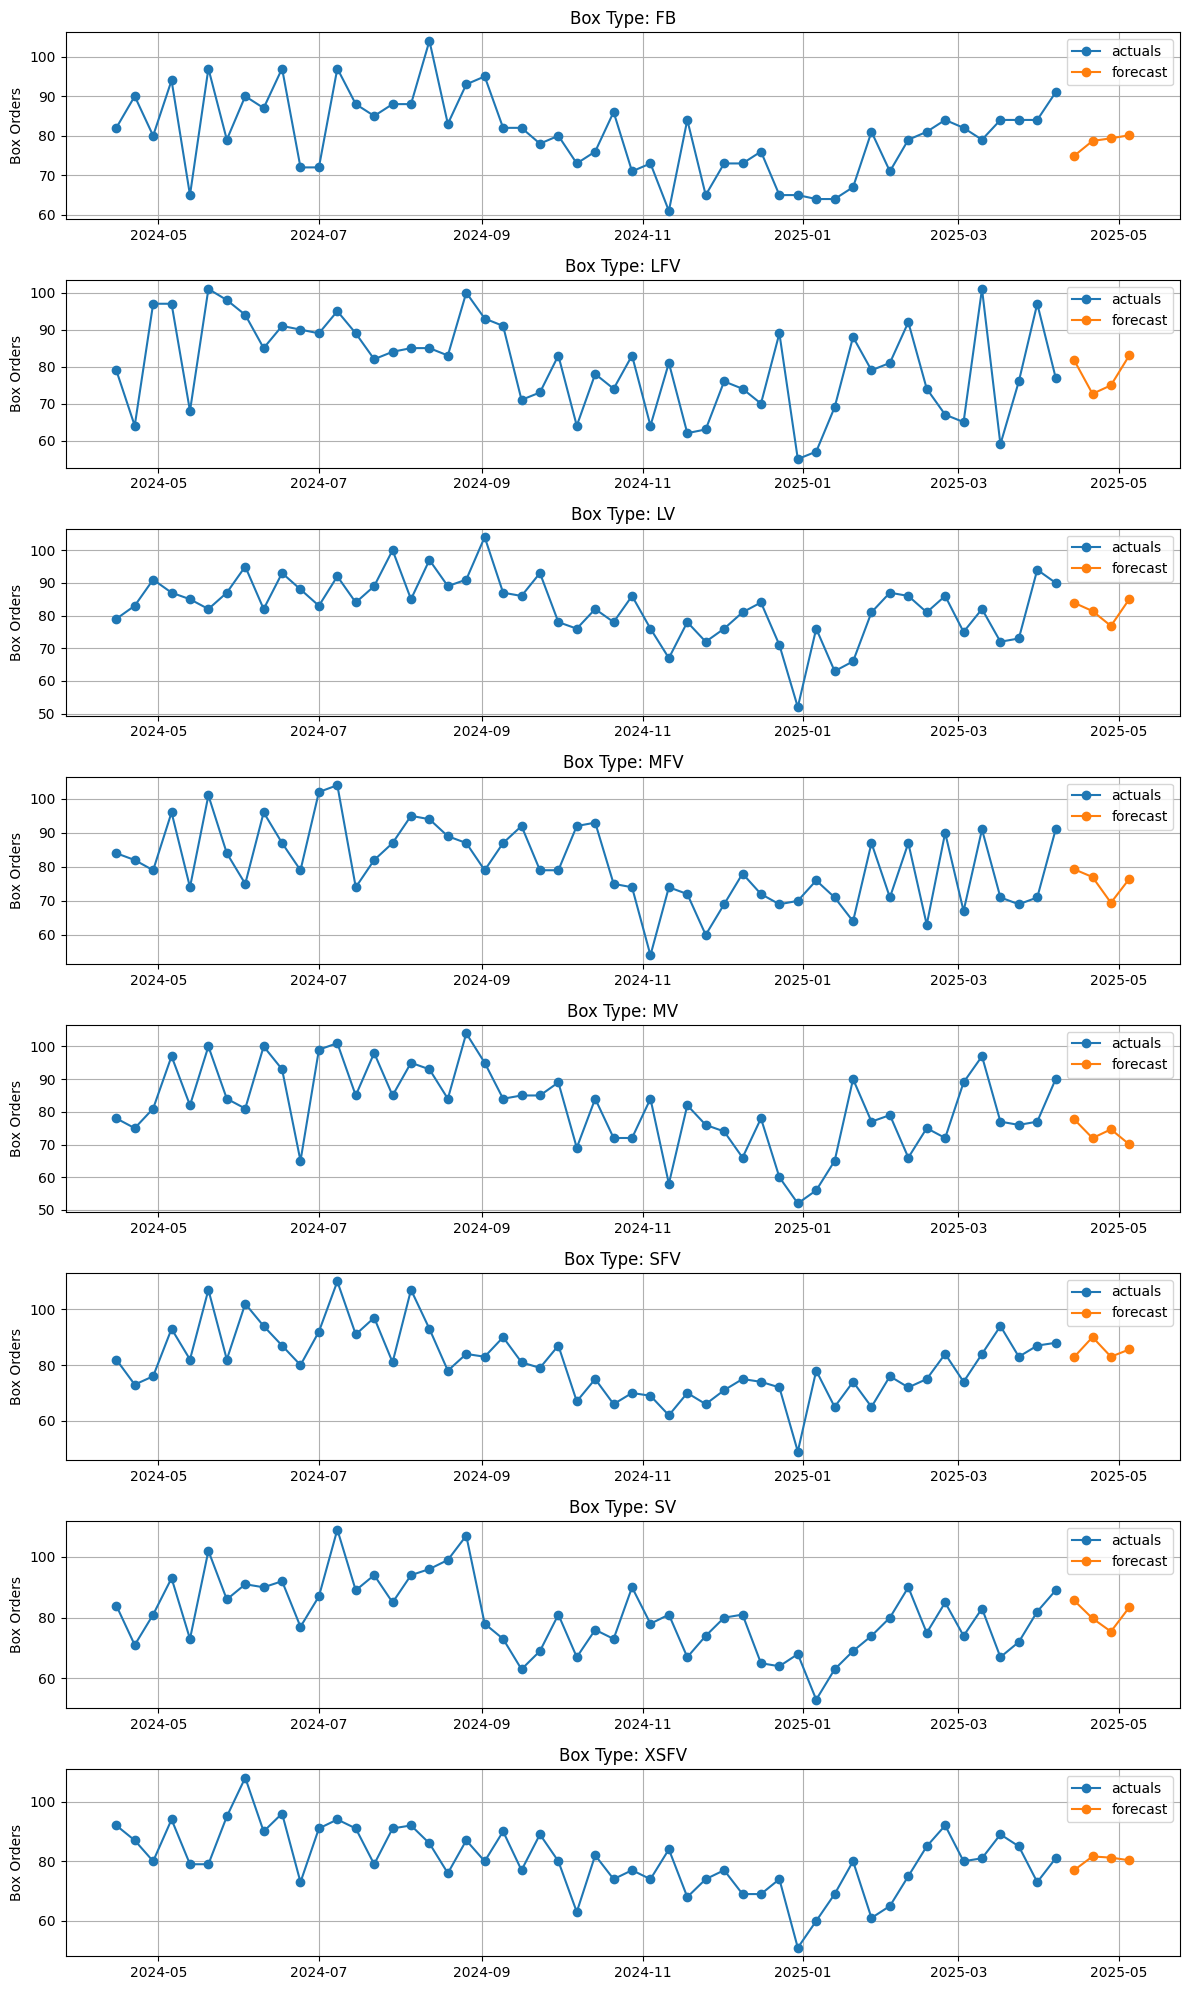

In [224]:
fig, axes = plt.subplots(n_box_types, 1, figsize=(12, 2.5 * n_box_types), sharex=False)
for ax, (ptype, group) in zip(axes, df_box_types_for_ts_w_forecast.replace(0, np.nan).groupby('box_type')):
    ax.plot(group['week'], group[['box_orders']], marker='o', label='actuals')
    ax.plot(group['week'], group[['predicted_orders']], marker='o', label='forecast')
    ax.set_title(f"Box Type: {ptype}")
    ax.set_ylabel("Box Orders")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()

### Save forecast output to csv

In [225]:
final_forecast.to_csv("weekly_box_orders_forecast_auto_sarimax.csv", index=False)

## Comments

In productions this would be build using functions and deployed using fastAPI so a JSON could be passed in via the front-end and forecasts can be obtained using the API which should be quick and structured. We could also run this as part of a weekly process with the outputs stored in a database to make for easier retrieval for the API. To containerise the solution we would use docker and ensure that we have separate github environment branches for optimal CI/CD.